# Movie Recommendation Engine
### Task 3 — Final Project (4-Week Track)

This notebook builds, evaluates, and demonstrates a movie recommendation
engine that combines:

1. **Content-based filtering** — TF-IDF vectorization of genres + plot
   overview, ranked with cosine similarity.
2. **Collaborative filtering** — matrix factorization (Truncated SVD)
   over a user-item ratings matrix, plus item-based nearest neighbours.
3. **A hybrid mode** that blends both signals.

The dataset is a reproducible, synthetically generated 300-movie /
200-user catalogue (see `src/generate_data.py`), so this notebook runs
fully offline with no external downloads.


## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 60)
%matplotlib inline


## 2. Load the data

If `data/movies.csv` / `data/ratings.csv` don't exist yet, generate them first by running `python src/generate_data.py` from the project root.

In [2]:
from data_loader import load_all

movies, ratings = load_all()
print(f"Movies: {len(movies)}")
print(f"Ratings: {len(ratings)}")
print(f"Users: {ratings['userId'].nunique()}")
movies.head()


Movies: 300
Ratings: 10766
Users: 200


,movieId,title,year,genres,overview,content_soup
0,1,Shattered Signal (2000),2000,Action,A story of rogue agent.,Action Action A story of rogue agent.
1,2,Last Frontier (2019),2019,Adventure,A story of treasure hunt.,Adventure Adventure A story of treasure hunt.
2,3,Last Kingdom (1999),1999,Thriller|Action|War,"A story of elite soldier, hidden identity and front-line...",Thriller Action War Thriller Action War A story of elite...
3,4,Forgotten Signal (1985),1985,Thriller|Horror|Animation,"A story of conspiracy unravels, whimsical adventure and ...",Thriller Horror Animation Thriller Horror Animation A st...
4,5,Distant Harbor (1991),1991,Horror,A story of haunted house.,Horror Horror A story of haunted house.


## 3. Exploratory data analysis

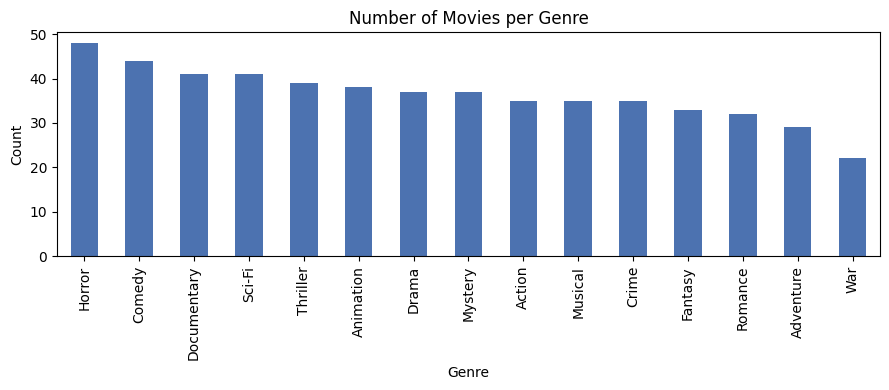

In [3]:
# Genre distribution
genre_counts = movies["genres"].str.split("|").explode().value_counts()

plt.figure(figsize=(9, 4))
genre_counts.plot(kind="bar", color="#4C72B0")
plt.title("Number of Movies per Genre")
plt.ylabel("Count")
plt.xlabel("Genre")
plt.tight_layout()
plt.show()


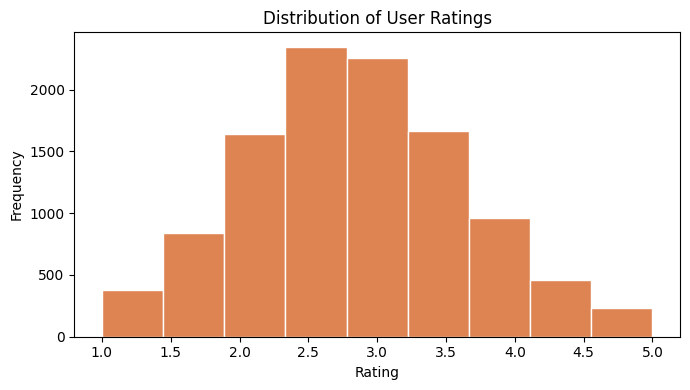

count    10766.000000
mean         2.824169
std          0.895291
min          1.000000
25%          2.000000
50%          3.000000
75%          3.500000
max          5.000000
Name: rating, dtype: float64

In [4]:
# Rating distribution
plt.figure(figsize=(7, 4))
ratings["rating"].plot(kind="hist", bins=9, color="#DD8452", edgecolor="white")
plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.tight_layout()
plt.show()

ratings["rating"].describe()


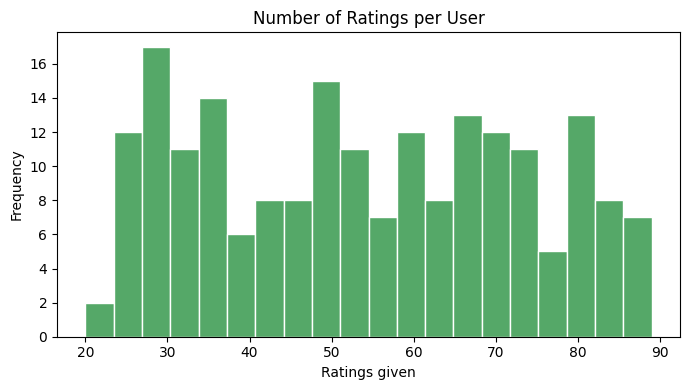

count    200.000000
mean      53.830000
std       19.358067
min       20.000000
25%       36.000000
50%       53.500000
75%       70.000000
max       89.000000
dtype: float64

In [5]:
# Ratings per user
ratings_per_user = ratings.groupby("userId").size()

plt.figure(figsize=(7, 4))
ratings_per_user.plot(kind="hist", bins=20, color="#55A868", edgecolor="white")
plt.title("Number of Ratings per User")
plt.xlabel("Ratings given")
plt.tight_layout()
plt.show()

ratings_per_user.describe()


## 4. Content-based filtering (TF-IDF + cosine similarity)

Each movie's genres (repeated for extra weight) and plot overview are
combined into a single text field, then vectorized with TF-IDF. Cosine
similarity between vectors gives a "how alike are these two movies"
score.

In [6]:
from content_based import ContentBasedRecommender

content_model = ContentBasedRecommender(movies)
print("TF-IDF matrix shape:", content_model.tfidf_matrix.shape)


TF-IDF matrix shape: (300, 835)


In [7]:
sample_title = movies.iloc[10]["title"]
print(f"Movies similar to: {sample_title}\n")
content_model.recommend_by_title(sample_title, top_n=10)


Movies similar to: Shattered Kingdom (1995)



,movieId,title,genres,similarity_score
0,254,Distant Legacy 3 (1989),Crime|Drama,0.5231
1,74,Distant Ascension (2018),Drama,0.3718
2,173,Silent Horizon 2 (2004),Drama,0.3718
3,73,Shattered Horizon (1991),Crime,0.2960
4,20,Wandering Shadow (2025),Mystery|Drama|Fantasy,0.2936
5,167,Golden Symphony (2015),Fantasy|Sci-Fi|Drama,0.2860
6,234,Hidden Signal 3 (2015),Horror|Fantasy,0.2388
7,107,Final Harbor (2014),Adventure|Fantasy,0.2324
8,147,Endless Requiem (2006),Action|Drama,0.2294
9,184,Forgotten Horizon (2018),Fantasy|Horror,0.2233


In [8]:
print("Top 'Sci-Fi' + 'Adventure' matches:\n")
content_model.recommend_by_genres(["Sci-Fi", "Adventure"], top_n=10)


Top 'Sci-Fi' + 'Adventure' matches:



,movieId,title,genres,similarity_score
0,162,Silent Covenant (2010),Adventure|Sci-Fi,0.6751
1,160,Crimson Covenant 2 (2004),Adventure|Sci-Fi,0.6694
2,104,Silent Reckoning (1997),Adventure|Sci-Fi|Fantasy,0.4213
3,69,Endless Frontier (2025),Sci-Fi,0.4185
4,274,Lost Ascension (2015),Sci-Fi,0.4185
5,163,Distant Descent (1999),Adventure|Animation|Sci-Fi,0.4182
6,35,Crimson Kingdom (1989),Sci-Fi,0.4155
7,138,Endless Horizon (2020),Sci-Fi,0.4155
8,196,Forgotten Signal 2 (2007),Sci-Fi,0.4058
9,79,Crimson Shadow (2003),Sci-Fi,0.3895


## 5. Collaborative filtering (matrix factorization)

The user-item ratings matrix is mean-centered per user (to remove
individual rating-scale bias) and factorized with `TruncatedSVD`. The
reconstructed matrix gives a predicted rating for every (user, movie)
pair, including ones the user hasn't rated — those are the
recommendation candidates.

In [9]:
from collaborative_filtering import CollaborativeRecommender

collab_model = CollaborativeRecommender(ratings, movies, n_factors=20)
print("User-item matrix shape:", collab_model.user_item_matrix.shape)


User-item matrix shape: (200, 300)


In [10]:
sample_user = collab_model.known_user_ids()[0]
print(f"Recommendations for user {sample_user}:\n")
collab_model.recommend_for_user(sample_user, top_n=10)


Recommendations for user 1:



,movieId,title,genres,predicted_rating
0,3,Last Kingdom (1999),Thriller|Action|War,3.81
1,177,Crimson Kingdom 2 (2008),Horror|Animation,3.70
2,92,Hidden Voyage 2 (2001),Documentary,3.55
3,82,Hidden Covenant 2 (2011),Animation|Thriller|Action,3.53
4,23,Distant Signal (2000),Musical|War,3.50
5,278,Broken Harbor (1999),Drama|Sci-Fi|Musical,3.50
6,134,Last Descent 3 (2010),Sci-Fi|Romance,3.49
7,89,Silent Ascension (2019),Animation,3.48
8,255,Distant Kingdom 3 (1987),Horror|Action,3.48
9,130,Distant Legacy 2 (2015),Mystery,3.47


In [11]:
sample_movie_id = int(movies.iloc[10]["movieId"])
print(f"Movies rated similarly to '{movies.iloc[10]['title']}':\n")
collab_model.similar_movies(sample_movie_id, top_n=10)


Movies rated similarly to 'Shattered Kingdom (1995)':



,movieId,title,genres,similarity_score
0,260,Final Frontier 3 (2003),Comedy,0.3550
1,188,Forgotten Reckoning (2005),Documentary|Crime,0.3267
2,235,Distant Echo 2 (2017),Mystery|Sci-Fi,0.3123
3,121,Golden Ascension (2003),Action|Horror,0.3090
4,223,Shattered Voyage 2 (2013),Horror,0.3070
5,246,Lost Frontier 2 (2024),Horror,0.3058
6,124,Golden Covenant 2 (1994),Musical,0.3041
7,180,Final Descent (1994),Horror|War|Musical,0.2998
8,47,Wandering Legacy (2001),Sci-Fi|Crime|Comedy,0.2947
9,151,Midnight Symphony 2 (2003),Crime,0.2862


## 6. Hybrid recommendations

Blends the normalized collaborative-filtering predicted rating with a content-based genre-affinity score derived from the user's top-rated movies.

In [12]:
from recommender import MovieRecommender

engine = MovieRecommender()
engine.hybrid_for_user(sample_user, top_n=10, cf_weight=0.6)


,movieId,title,genres,hybrid_score
0,3,Last Kingdom (1999),Thriller|Action|War,0.600000
1,177,Crimson Kingdom 2 (2008),Horror|Animation,0.462500
2,107,Final Harbor (2014),Adventure|Fantasy,0.400000
3,23,Distant Signal (2000),Musical|War,0.313386
4,26,Forgotten Echo (1998),Fantasy|War,0.288700
5,18,Silent Frontier (1992),Fantasy|War,0.284733
6,141,Golden Echo 2 (2015),Fantasy|Adventure,0.283316
7,92,Hidden Voyage 2 (2001),Documentary,0.275000
8,82,Hidden Covenant 2 (2011),Animation|Thriller|Action,0.250000
9,46,Shattered Signal 2 (2024),War|Fantasy,0.234431


## 7. Performance evaluation

We evaluate:
- **Content-based**: intra-list genre-overlap coherence + build/query timing.
- **Collaborative filtering**: RMSE / MAE on a held-out 20% split, and
  Precision@10 / Recall@10 for the top-N recommendation task, plus
  build/query timing.

This directly maps model efficiency (how fast) against user requests
(how relevant/accurate).

In [13]:
from evaluation import generate_report
import json

report = generate_report()
print(json.dumps(report, indent=2))


{
  "dataset_summary": {
    "n_movies": 300,
    "n_ratings": 10766,
    "n_users": 200,
    "avg_ratings_per_user": 53.83
  },
  "content_based": {
    "model_build_time_sec": 0.006,
    "avg_query_time_sec": 0.002169,
    "avg_intra_list_genre_overlap": 0.6933,
    "n_queries": 30
  },
  "collaborative_filtering": {
    "model_build_time_sec": 0.0141,
    "rmse": 0.907,
    "mae": 0.7271,
    "avg_query_time_sec": 0.002489,
    "precision_at_10": 0.0225,
    "recall_at_10": 0.0898,
    "n_users_evaluated": 40
  }
}


A full write-up of these results (with interpretation) is saved to `docs/performance_report.md`.

## 8. Live demo queries

A few end-to-end example queries a real user of the console/Streamlit app
might make.

In [14]:
print("Demo 1: 'I liked ...' -> similar movies")
demo_title = movies.iloc[42]["title"]
print(f"Seed movie: {demo_title}\n")
display(engine.by_title(demo_title, top_n=5))


Demo 1: 'I liked ...' -> similar movies
Seed movie: Lost Legacy 2 (2004)



,movieId,title,genres,similarity_score
0,84,Lost Voyage 2 (1986),Horror|Sci-Fi,0.8833
1,207,Hidden Descent 2 (1993),Sci-Fi,0.6746
2,67,Lost Descent (2022),Sci-Fi|Horror,0.5064
3,45,Broken Symphony (2007),Horror|Fantasy|Sci-Fi,0.5037
4,158,Crimson Signal (1985),Crime|Sci-Fi,0.4833


In [15]:
print("Demo 2: genre-based discovery")
display(engine.by_genres(["Horror", "Mystery"], top_n=5))


Demo 2: genre-based discovery


,movieId,title,genres,similarity_score
0,101,Crimson Requiem (2024),Horror|Mystery,0.6799
1,215,Final Harbor 3 (1994),Fantasy|Horror|Mystery,0.4900
2,105,Crimson Frontier 2 (2016),Mystery|Horror|Adventure,0.3407
3,117,Distant Reckoning 2 (2009),Mystery|Documentary|Horror,0.3200
4,76,Crimson Frontier (2018),Mystery,0.1984


In [16]:
print("Demo 3: personalized recommendations for a returning user")
demo_user = engine.known_users()[5]
display(engine.for_user(demo_user, top_n=5))


Demo 3: personalized recommendations for a returning user


,movieId,title,genres,predicted_rating
0,295,Final Horizon (2010),Mystery|Thriller,3.06
1,231,Forgotten Legacy 2 (2023),Musical|Mystery,3.05
2,145,Eternal Kingdom (2000),Musical|Romance,3.04
3,37,Lost Symphony (1988),Horror|War,3.03
4,50,Crimson Reckoning (2012),Drama|Adventure,3.03


## 9. Conclusion

- The content-based model gives coherent, explainable recommendations
  ("this is similar because it shares genres X, Y") and works even for
  brand-new users with no rating history (no cold-start problem).
- The collaborative-filtering model captures cross-genre taste patterns
  that pure content similarity can't see, but needs enough rating
  history per user to be reliable.
- The hybrid mode gets the best of both: personalized where history
  exists, content-driven where it doesn't.
- See `docs/architecture.md` for the full system design and
  `docs/performance_report.md` for the complete metrics write-up.
